In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from google.colab import drive
drive.mount('/content/drive')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

train = pd.read_csv('/content/drive/MyDrive/GDG Al-Zaher || Data Science || 2026/Final Project/Preprocessed Data/train_data.csv')
test = pd.read_csv('/content/drive/MyDrive/GDG Al-Zaher || Data Science || 2026/Final Project/Preprocessed Data/test_data.csv')

TARGET = "Yield"

FEATURES_NUM = [
    "Yield_Lag1",
    "Yield_Lag2",
    "Production_Lag1",
    "Area_Lag1",
    "Yield_RollingMean_3Y",
    "Area_Growth_Lag1",
    "Production_Growth_Lag1"
]

FEATURES = ["Item"] + FEATURES_NUM

print("Train:", train.shape)
print("Test :", test.shape)

print("\nTrain years:", train["Year"].min(), "-", train["Year"].max())
print("Test years :", test["Year"].min(), "-", test["Year"].max())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (3502, 10)
Test : (827, 10)

Train years: 1964 - 2013
Test years : 2014 - 2024


In [4]:
# Sort by year to preserve the temporal order
train = train.sort_values("Year").reset_index(drop=True)

# Use the latest 20% of training years as validation
unique_years = sorted(train["Year"].unique())

split_idx = int(len(unique_years) * 0.80)

train_years = unique_years[:split_idx]
val_years = unique_years[split_idx:]

train_model = train[train["Year"].isin(train_years)].copy()
validation = train[train["Year"].isin(val_years)].copy()

print("Model Training Set:")
print(train_model.shape)
print("Years:", train_model["Year"].min(), "-", train_model["Year"].max())

print("\nValidation Set:")
print(validation.shape)
print("Years:", validation["Year"].min(), "-", validation["Year"].max())

print("\nFinal Test Set:")
print(test.shape)
print("Years:", test["Year"].min(), "-", test["Year"].max())

Model Training Set:
(2742, 10)
Years: 1964 - 2003

Validation Set:
(760, 10)
Years: 2004 - 2013

Final Test Set:
(827, 10)
Years: 2014 - 2024


In [5]:
X_train = pd.get_dummies(
    train_model[FEATURES],
    columns=["Item"],
    prefix="Item"
)

X_val = pd.get_dummies(
    validation[FEATURES],
    columns=["Item"],
    prefix="Item"
)

X_test = pd.get_dummies(
    test[FEATURES],
    columns=["Item"],
    prefix="Item"
)

# Make validation and test have exactly the same columns as training
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_model[TARGET]
y_val = validation[TARGET]
y_test = test[TARGET]

print("Feature matrix:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Feature matrix:
Train: (2742, 83)
Validation: (760, 83)
Test: (827, 83)


In [6]:
scaler = StandardScaler()

X_train[FEATURES_NUM] = scaler.fit_transform(
    X_train[FEATURES_NUM]
)

X_val[FEATURES_NUM] = scaler.transform(
    X_val[FEATURES_NUM]
)

X_test[FEATURES_NUM] = scaler.transform(
    X_test[FEATURES_NUM]
)

In [7]:
baseline_val_pred = validation["Yield_Lag1"]
baseline_test_pred = test["Yield_Lag1"]

def evaluate_model(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

baseline_val = evaluate_model(
    y_val,
    baseline_val_pred,
    "Persistence Baseline"
)

baseline_test = evaluate_model(
    y_test,
    baseline_test_pred,
    "Persistence Baseline"
)

print("Baseline — Validation")
print(pd.DataFrame([baseline_val]).round(3))

print("\nBaseline — Test")
print(pd.DataFrame([baseline_test]).round(3))

Baseline — Validation
                  Model      MAE          MSE      RMSE     R2
0  Persistence Baseline  994.506  6180061.752  2485.973  0.978

Baseline — Test
                  Model      MAE          MSE      RMSE     R2
0  Persistence Baseline  929.056  7138786.605  2671.851  0.973


In [8]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_val_pred = linear_model.predict(X_val)
linear_test_pred = linear_model.predict(X_test)

linear_val = evaluate_model(
    y_val,
    linear_val_pred,
    "Linear Regression"
)

linear_test = evaluate_model(
    y_test,
    linear_test_pred,
    "Linear Regression"
)

print("Linear Regression — Validation")
print(pd.DataFrame([linear_val]).round(3))

print("\nLinear Regression — Test")
print(pd.DataFrame([linear_test]).round(3))

Linear Regression — Validation
               Model       MAE          MSE      RMSE     R2
0  Linear Regression  1169.876  6033105.621  2456.238  0.979

Linear Regression — Test
               Model       MAE          MSE      RMSE     R2
0  Linear Regression  1139.539  6238885.768  2497.776  0.977


In [9]:
depths = [3, 4, 5, 6, 7, 8, 10, 12, 15]

tuning_results = []

for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    tuning_results.append({
        "max_depth": depth,
        "MAE": mean_absolute_error(y_val, pred),
        "RMSE": np.sqrt(mean_squared_error(y_val, pred)),
        "R2": r2_score(y_val, pred)
    })

tuning_results = pd.DataFrame(tuning_results)

display(tuning_results.round(3))

,max_depth,MAE,RMSE,R2
0,3,2893.395,4638.183,0.923
1,4,1836.530,3260.645,0.962
2,5,1400.267,2705.297,0.974
3,6,1300.589,2803.419,0.972
4,7,1284.018,2919.931,0.970
5,8,1300.526,2884.258,0.970
6,10,1345.191,2956.616,0.969
7,12,1378.316,2964.162,0.969
8,15,1514.660,3096.982,0.966


In [10]:
best_depth = tuning_results.loc[
    tuning_results["RMSE"].idxmin(),
    "max_depth"
]

print("Best max_depth:", best_depth)

Best max_depth: 5


In [11]:
best_tree = DecisionTreeRegressor(
    max_depth=int(best_depth),
    random_state=42
)

best_tree.fit(X_train, y_train)

tree_val_pred = best_tree.predict(X_val)
tree_test_pred = best_tree.predict(X_test)

tree_val = evaluate_model(
    y_val,
    tree_val_pred,
    "Tuned Decision Tree"
)

tree_test = evaluate_model(
    y_test,
    tree_test_pred,
    "Tuned Decision Tree"
)

print("Tuned Decision Tree — Validation")
print(pd.DataFrame([tree_val]).round(3))

print("\nTuned Decision Tree — Test")
print(pd.DataFrame([tree_test]).round(3))

Tuned Decision Tree — Validation
                 Model       MAE          MSE      RMSE     R2
0  Tuned Decision Tree  1400.267  7318631.304  2705.297  0.974

Tuned Decision Tree — Test
                 Model       MAE          MSE      RMSE     R2
0  Tuned Decision Tree  1360.753  7261011.972  2694.626  0.973


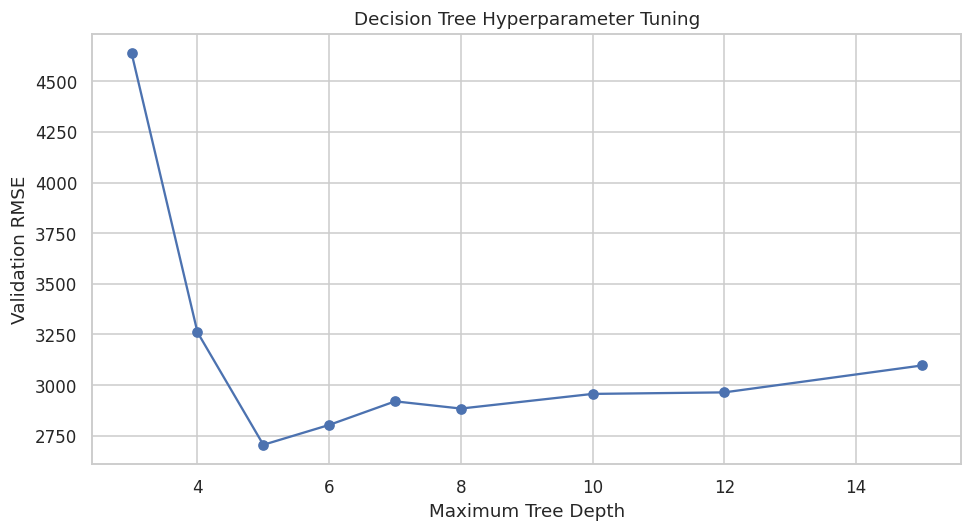

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    tuning_results["max_depth"],
    tuning_results["RMSE"],
    marker="o"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Validation RMSE")
plt.title("Decision Tree Hyperparameter Tuning")

plt.tight_layout()
plt.show()

In [13]:
final_results = pd.DataFrame([
    baseline_test,
    linear_test,
    tree_test
])

display(
    final_results.round(3)
)

,Model,MAE,MSE,RMSE,R2
0,Persistence Baseline,929.056,7138786.605,2671.851,0.973
1,Linear Regression,1139.539,6238885.768,2497.776,0.977
2,Tuned Decision Tree,1360.753,7261011.972,2694.626,0.973


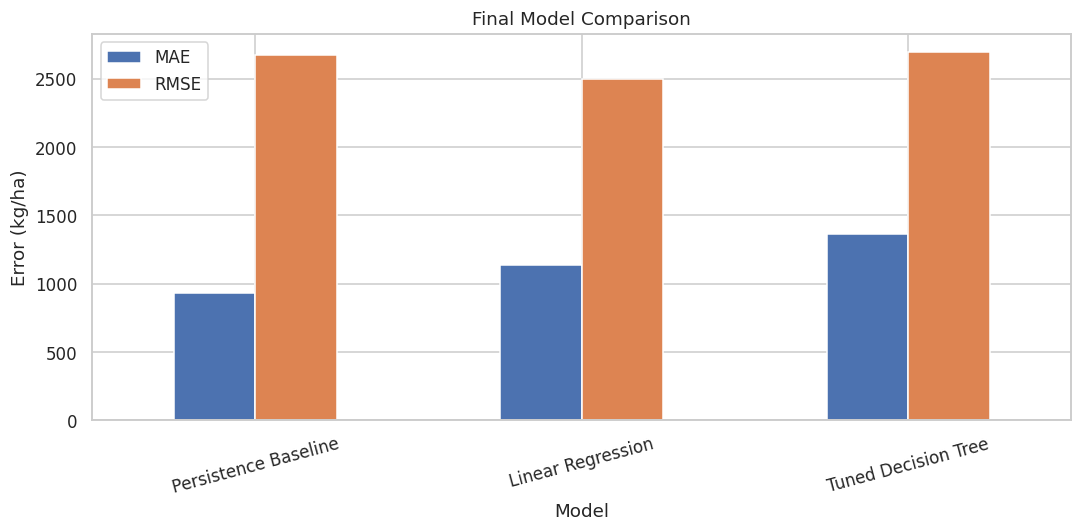

In [14]:
comparison = final_results.set_index("Model")[["MAE", "RMSE"]]

comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Final Model Comparison")
plt.ylabel("Error (kg/ha)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

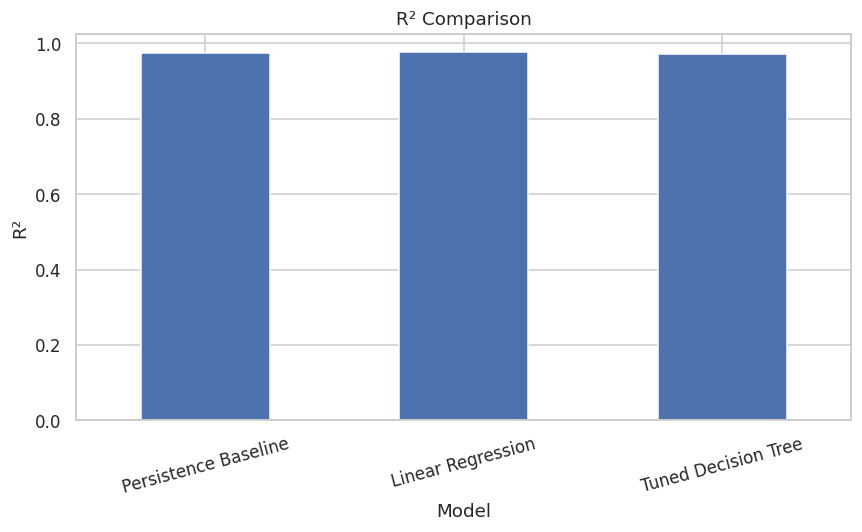

In [15]:
final_results.set_index("Model")["R2"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("R² Comparison")
plt.ylabel("R²")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [16]:
error_df = test[["Item", "Year", "Yield", "Yield_Lag1"]].copy()

error_df["Baseline_Pred"] = baseline_test_pred.values
error_df["Linear_Pred"] = linear_test_pred
error_df["Tree_Pred"] = tree_test_pred

error_df["Baseline_Abs_Error"] = (
    error_df["Yield"] - error_df["Baseline_Pred"]
).abs()

error_df["Linear_Abs_Error"] = (
    error_df["Yield"] - error_df["Linear_Pred"]
).abs()

error_df["Tree_Abs_Error"] = (
    error_df["Yield"] - error_df["Tree_Pred"]
).abs()

display(error_df.head())

,Item,Year,Yield,Yield_Lag1,Baseline_Pred,Linear_Pred,Tree_Pred,Baseline_Abs_Error,Linear_Abs_Error,Tree_Abs_Error
0,"Anise, badian, coriander, cumin, caraway, fenn...",2014,881.4,885.6,885.6,848.560194,1519.677609,4.2,32.839806,638.277609
1,"Anise, badian, coriander, cumin, caraway, fenn...",2015,884.9,881.4,881.4,847.750611,1519.677609,3.5,37.149389,634.777609
2,"Anise, badian, coriander, cumin, caraway, fenn...",2016,887.1,884.9,884.9,842.300432,1519.677609,2.2,44.799568,632.577609
3,"Anise, badian, coriander, cumin, caraway, fenn...",2017,890.7,887.1,887.1,842.497643,1519.677609,3.6,48.202357,628.977609
4,"Anise, badian, coriander, cumin, caraway, fenn...",2018,893.1,890.7,890.7,844.351900,1519.677609,2.4,48.748100,626.577609


In [17]:
crop_errors = error_df.groupby("Item").agg(
    Baseline_MAE=("Baseline_Abs_Error", "mean"),
    Linear_MAE=("Linear_Abs_Error", "mean"),
    Tree_MAE=("Tree_Abs_Error", "mean")
)

crop_errors["Linear_vs_Baseline"] = (
    crop_errors["Linear_MAE"] -
    crop_errors["Baseline_MAE"]
)

crop_errors["Tree_vs_Baseline"] = (
    crop_errors["Tree_MAE"] -
    crop_errors["Baseline_MAE"]
)

display(
    crop_errors.sort_values("Linear_MAE", ascending=False)
    .round(2)
)

,Baseline_MAE,Linear_MAE,Tree_MAE,Linear_vs_Baseline,Tree_vs_Baseline
Item,,,,,
Sugar beet,5459.83,9124.84,5008.27,3665.01,-451.56
Sugar cane,8328.13,7443.84,8938.98,-884.29,610.85
Watermelons,2422.79,2766.62,3012.94,343.83,590.15
Sweet potatoes,2150.26,2671.18,2933.79,520.92,783.52
Dates,2170.95,2600.88,3175.58,429.92,1004.62
...,...,...,...,...,...
Other pulses n.e.c.,8.23,45.66,422.15,37.43,413.93
"Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw",3.87,43.85,630.54,39.97,626.67
"Walnuts, in shell",4.12,30.06,165.86,25.94,161.74


In [18]:
error_df["Yield_Level"] = pd.qcut(
    error_df["Yield"],
    q=5,
    duplicates="drop"
)

yield_level_errors = error_df.groupby(
    "Yield_Level",
    observed=True
).agg(
    Baseline_MAE=("Baseline_Abs_Error", "mean"),
    Linear_MAE=("Linear_Abs_Error", "mean"),
    Tree_MAE=("Tree_Abs_Error", "mean")
)

display(yield_level_errors.round(2))

,Baseline_MAE,Linear_MAE,Tree_MAE
Yield_Level,,,
"(871.899, 3146.42]",165.90,199.22,453.10
"(3146.42, 7543.84]",297.91,604.93,609.90
"(7543.84, 15730.96]",718.65,811.04,1013.04
"(15730.96, 26832.18]",1103.36,1381.72,1376.35
"(26832.18, 115355.2]",2355.43,2697.04,3344.85


In [19]:
error_df["Best_Model_Error"] = error_df[
    ["Baseline_Abs_Error", "Linear_Abs_Error", "Tree_Abs_Error"]
].min(axis=1)

error_df["Best_Model"] = error_df[
    ["Baseline_Abs_Error", "Linear_Abs_Error", "Tree_Abs_Error"]
].idxmin(axis=1)

worst_predictions = error_df.sort_values(
    "Best_Model_Error",
    ascending=False
).head(15)

display(
    worst_predictions[
        [
            "Item",
            "Year",
            "Yield",
            "Baseline_Pred",
            "Linear_Pred",
            "Tree_Pred",
            "Best_Model_Error",
            "Best_Model"
        ]
    ].round(2)
)

,Item,Year,Yield,Baseline_Pred,Linear_Pred,Tree_Pred,Best_Model_Error,Best_Model
723,Sugar cane,2020,72879.7,110877.1,113323.26,118487.30,37997.40,Baseline_Abs_Error
712,Sugar beet,2020,72814.8,48158.8,55415.61,47199.28,17399.19,Linear_Abs_Error
397,"Onions and shallots, dry (excluding dehydrated)",2014,36579.0,20737.3,26213.28,23148.56,10365.72,Linear_Abs_Error
40,Artichokes,2021,28523.9,18791.5,19359.39,17994.00,9164.51,Linear_Abs_Error
746,Sweet potatoes,2021,35227.2,27656.7,28453.41,26335.91,6773.79,Linear_Abs_Error
260,Grapes,2020,15040.3,22000.0,21373.99,23148.56,6333.69,Linear_Abs_Error
228,Eggplants (aubergines),2021,33457.9,27262.7,26873.07,26335.91,6195.20,Baseline_Abs_Error
512,Peaches and nectarines,2018,21074.6,16246.8,14552.33,14965.19,4827.80,Baseline_Abs_Error
142,Cauliflowers and broccoli,2023,28248.6,22250.8,23624.10,23148.56,4624.50,Linear_Abs_Error
745,Sweet potatoes,2020,27656.7,33488.2,32129.88,32195.19,4473.18,Linear_Abs_Error


In [20]:
feature_names = X_train.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_tree.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(importance_df.head(15).round(4))

,Feature,Importance
73,Item_Sugar cane,0.5305
0,Yield_Lag1,0.3936
4,Yield_RollingMean_3Y,0.0653
2,Production_Lag1,0.0100
3,Area_Lag1,0.0003
5,Area_Growth_Lag1,0.0002
6,Production_Growth_Lag1,0.0000
7,"Item_Anise, badian, coriander, cumin, caraway,...",0.0000
8,Item_Apples,0.0000
9,Item_Apricots,0.0000


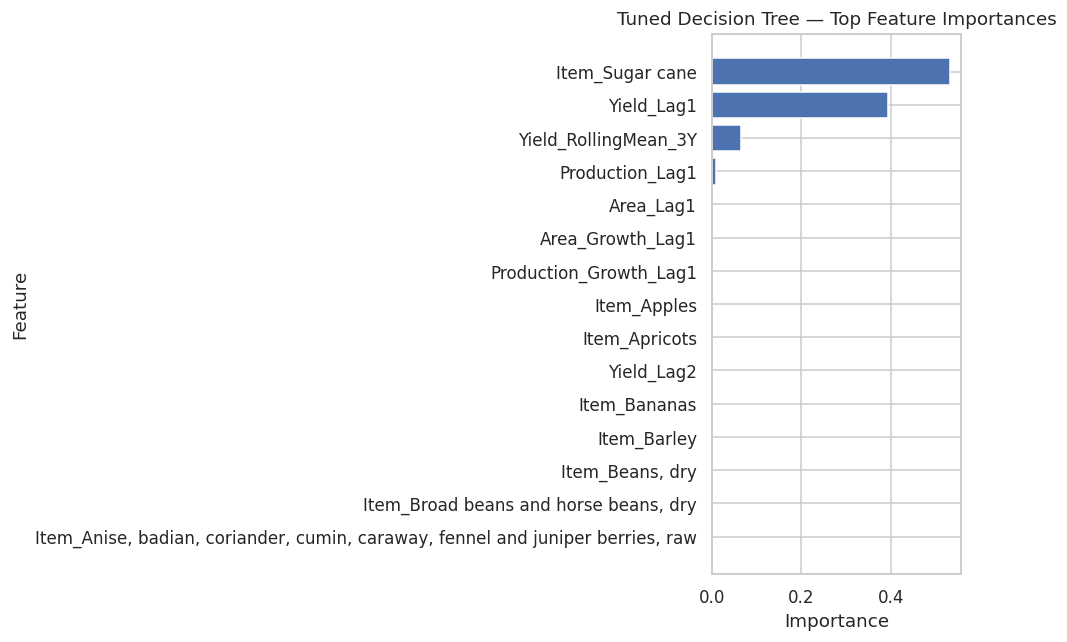

In [21]:
top_importance = importance_df.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_importance["Feature"],
    top_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Tuned Decision Tree — Top Feature Importances")

plt.tight_layout()
plt.show()

Selected model for final visualization: Linear Regression


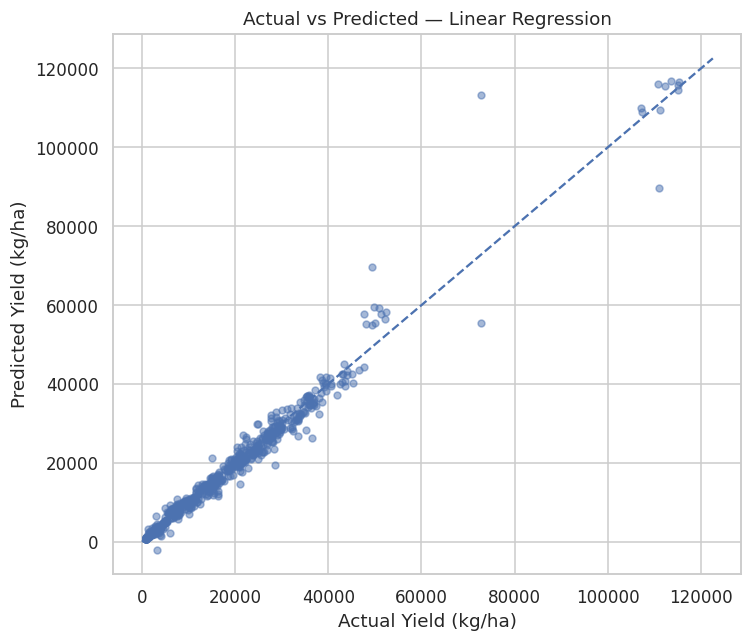

In [22]:
predictions = {
    "Persistence Baseline": baseline_test_pred,
    "Linear Regression": linear_test_pred,
    "Tuned Decision Tree": tree_test_pred
}

test_rmse = {
    name: np.sqrt(mean_squared_error(y_test, pred))
    for name, pred in predictions.items()
}

best_model_name = min(
    test_rmse,
    key=test_rmse.get
)

best_predictions = predictions[best_model_name]

print("Selected model for final visualization:", best_model_name)

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5,
    s=20
)

lims = [
    0,
    max(y_test.max(), best_predictions.max()) * 1.05
]

plt.plot(
    lims,
    lims,
    "--",
    linewidth=1.5
)

plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")
plt.title(f"Actual vs Predicted — {best_model_name}")

plt.tight_layout()
plt.show()

In [23]:
print("FINAL MODEL PERFORMANCE")
print("=" * 60)

display(
    final_results
    .sort_values("RMSE")
    .round(3)
)

FINAL MODEL PERFORMANCE


,Model,MAE,MSE,RMSE,R2
1,Linear Regression,1139.539,6238885.768,2497.776,0.977
0,Persistence Baseline,929.056,7138786.605,2671.851,0.973
2,Tuned Decision Tree,1360.753,7261011.972,2694.626,0.973


# Final Findings

- The persistence baseline provides a strong reference because current-year yield is strongly related to recent historical yield.
- Linear Regression captures the main linear relationships between historical yield, crop identity, and other lagged agricultural variables.
- Decision Tree performance is evaluated before and after hyperparameter tuning using a chronological validation set.
- Final model performance is evaluated on the held-out test set using MAE, MSE, RMSE, and R².
- Error analysis is performed across crops and yield levels to identify where prediction errors are concentrated.
- Feature importance from the tuned Decision Tree provides an additional interpretation of the predictive structure.
- The results should be interpreted as predictive relationships rather than causal agricultural effects.